In [1]:
# MINOR PROJECT
import pandas as pd
from sklearn.metrics import precision_score, accuracy_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("loan_approval_data.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handle Missing Values


In [3]:
# To fill Numerical columns with missing values, like age, amount, we can fill them by filling with mean, median
# For categorical values like gender, we can use mode--> most frequent

categorical_cols= df.select_dtypes(include=["object"]).columns # to gather all the non-numerical problems
numerical_cols= df.select_dtypes(include=["float64", "int64"]).columns # to gather numerical columns

In [4]:
# Now we will fill categorical columns with a different technique and numerical columns with a different one
#Imputer-sklearn --> helps in filling missing values with simple startegies(mean, mediam, mode)


from sklearn.impute import SimpleImputer
#Filling numerical columns
num_imp= SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

# Filling Categorical Cols
cat_imp= SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])


In [5]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'Is loan approved or not')

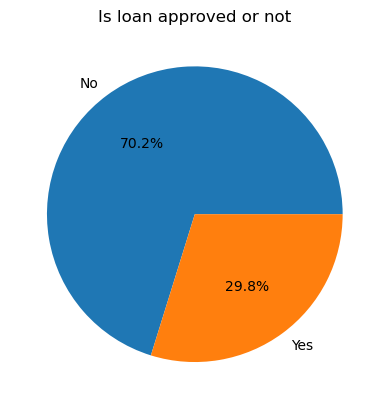

In [6]:
# How balanced our classes are
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is loan approved or not")

<Axes: xlabel='Gender', ylabel='count'>

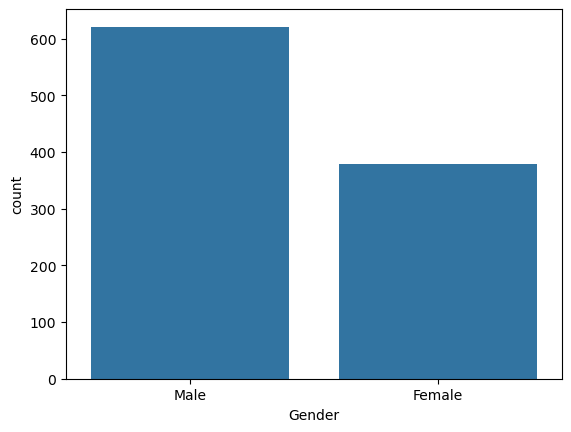

In [7]:
# Analyse categories
gender_count=df["Gender"].value_counts()
sns.barplot(gender_count)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

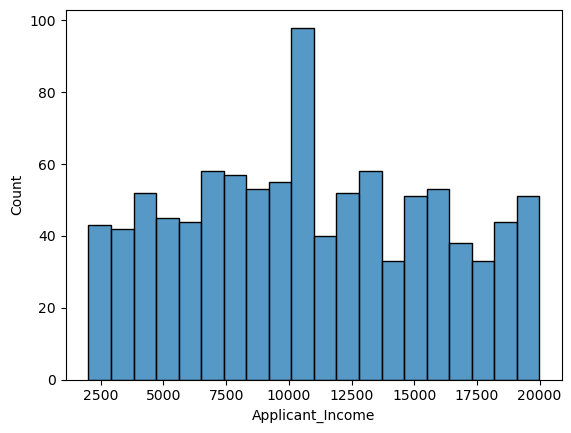

In [8]:
#analyze income
sns.histplot(
    data= df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

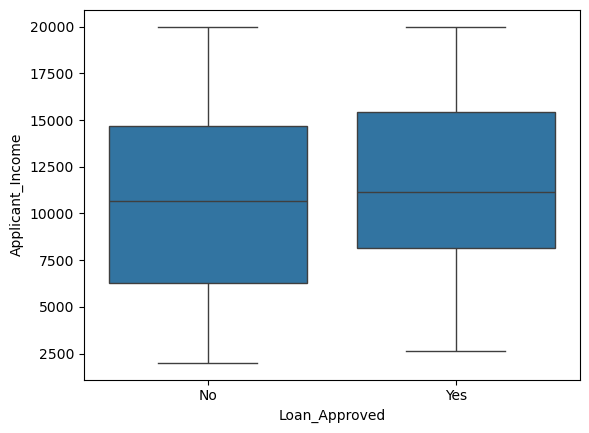

In [9]:
# Outliers detection- boxplot
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)
#shows that income is a good factor and with low income, chances of getting rejected are  more

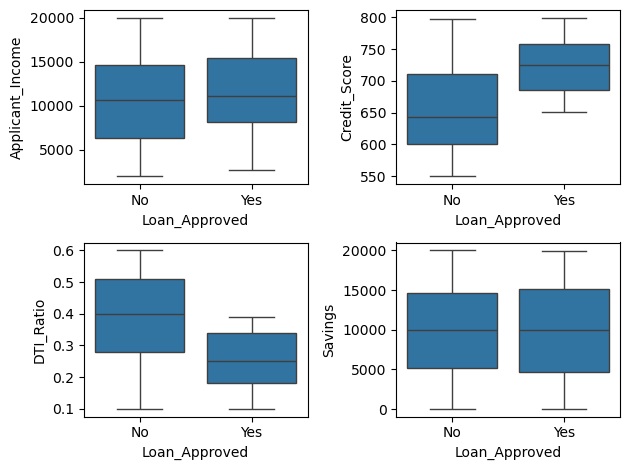

In [10]:
# Subplots
fig, axes= plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

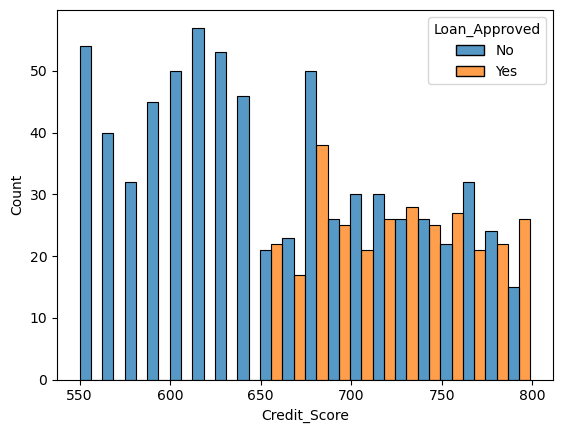

In [11]:
 # Credit score and Loan Approved
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
) 

# FEATURE ENCODING

In [12]:
df=df.drop("Applicant_ID", axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [13]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [14]:
# Now we need to encode the categorical columns into numbers

# 1) LabelEncoder- Assigns an integer to each category --> Assign integers 0,1,2,3 to the column depending on the categories, used for ordinal data
# bascially used for data which has some order, example- education level, difficulty level
# for output or the target variable, always LabelEncoder is used


# 2) OneHotEncoder --> used for nominal data- every category is equal, means in Gender, earlier we used to 
# give M as 1 and F as 0, but then the model will think that F is less important than M


#LabelEncoder
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])


#OneHotEncoder
cols=["Employment_Status","Marital_Status", "Loan_Purpose", "Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols]) # this will return an array, we need to convert it into DataFrame

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols), index=df.index)
df=pd.concat([df.drop(columns=cols), encoded_df] , axis=1)  # add new columns to original df


In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation HeatMap

In [16]:
# Helps to tell that how much the features are related to each other
# ranges from -1 to 1 where 1 is perfect and -1 is negative correlation
nums_cols= df.select_dtypes(include="number")
corr_matrix=nums_cols.corr()
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False) #tells the relation of each feature with the target

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

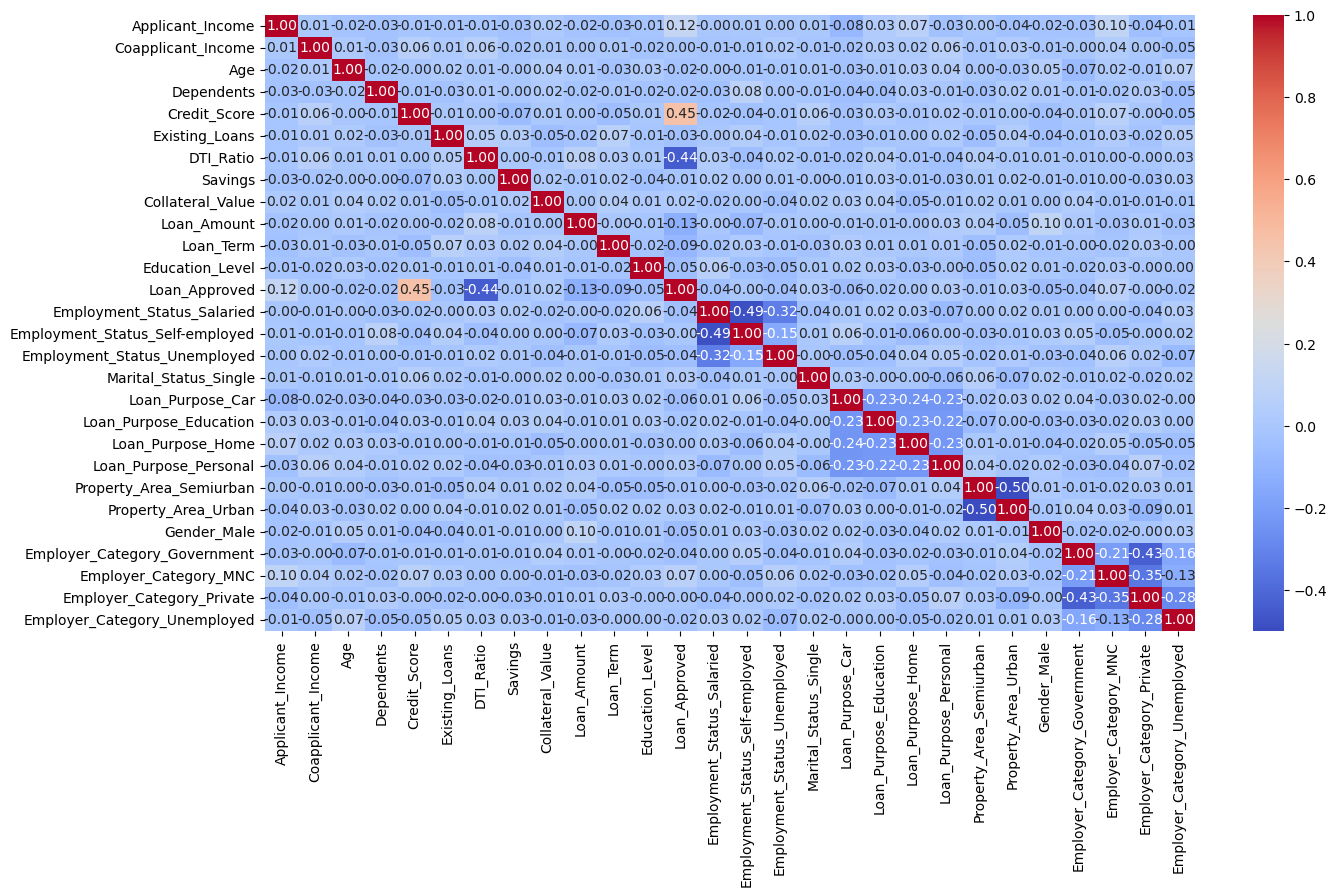

In [17]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


# Train Test Split and Feature Scaling

In [18]:
X=df.drop("Loan_Approved", axis=1)
y=df["Loan_Approved"]

In [19]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [20]:
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
#Scaling

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)



# Training and Evaluating

In [22]:
# Logistic Regression
log_model=LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred=log_model.predict(X_test_scaled)

In [23]:
# Evaluation

from sklearn.metrics import confusion_matrix, f1_score

print("Precision ", precision_score(y_test, y_pred))
print("Accuracy ", accuracy_score(y_test, y_pred))
print("Recall ", recall_score(y_test, y_pred))
print("F1 Score ", f1_score(y_test, y_pred))
print("CM ", confusion_matrix(y_test, y_pred))

Precision  0.7833333333333333
Accuracy  0.865
Recall  0.7704918032786885
F1 Score  0.7768595041322314
CM  [[126  13]
 [ 14  47]]


In [24]:
# KNN
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred=knn_model.predict(X_test_scaled)

# Evaluation

print("Precision ", precision_score(y_test, y_pred))
print("Accuracy ", accuracy_score(y_test, y_pred))
print("Recall ", recall_score(y_test, y_pred))
print("F1 Score ", f1_score(y_test, y_pred))
print("CM ", confusion_matrix(y_test, y_pred))

Precision  0.6274509803921569
Accuracy  0.76
Recall  0.5245901639344263
F1 Score  0.5714285714285714
CM  [[120  19]
 [ 29  32]]


In [25]:
#Naive bayes
nb_model=GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred=nb_model.predict(X_test_scaled)

# Evaluation

print("Precision ", precision_score(y_test, y_pred))
print("Accuracy ", accuracy_score(y_test, y_pred))
print("Recall ", recall_score(y_test, y_pred))
print("F1 Score ", f1_score(y_test, y_pred))
print("CM ", confusion_matrix(y_test, y_pred))



Precision  0.8035714285714286
Accuracy  0.865
Recall  0.7377049180327869
F1 Score  0.7692307692307693
CM  [[128  11]
 [ 16  45]]


# Best Model on the basis of Precision is - Naive Bayes

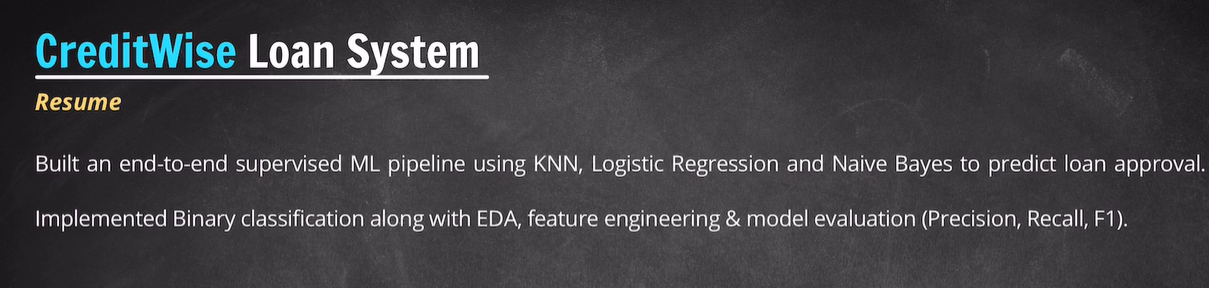

In [26]:
import pickle
pickle.dump(nb_model, open("model.pkl", "wb"))

In [27]:
X.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

In [28]:
import pickle

# Save model
pickle.dump(nb_model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [30]:
X_train_scaled.shape

(800, 27)

In [29]:
import pickle

pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

In [30]:
import pickle

# SAVE THE CORRECT MODEL (Logistic)
pickle.dump(log_model, open("model.pkl", "wb"))

# Save scaler (already correct)
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save columns
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Fit scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
import pickle

pickle.dump(log_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))